# 1- Charger et explorer les données

In [2]:
import pandas as pd # for data manipulation
import numpy as np # for numerical operations 

In [3]:
path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)

In [4]:
print(df.head()) # to check the first few rows of the dataset (to get an overview of the data and to see if there are any missing values or inconsistencies that need to be addressed before analysis)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
df.duplicated().sum() # to check for duplicate rows in the dataset (to see if there are any duplicate entries that could affect our analysis)

np.int64(0)

In [6]:
print(df.shape) # to check the number of rows and columns in the dataset
print(df.info()) # to check the data types of each column and to see if there are any missing values

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [7]:
print(df.describe()) # to get a statistical summary of the numerical columns in the dataset

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [8]:
print(df["Churn"].value_counts()) # to check the distribution of the target variable
print(df["Churn"].value_counts(normalize=True) * 100) # to check the distribution of the target variable in percentage (effectif de la catégorie / effectif total)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
print(df.isnull().sum()) # to check the number of missing values in each column (if there are any missing values, we will need to handle them before building our model)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# 2- Nettoyage minimal (très important avant ML)

In [10]:
df = df.drop(columns=["customerID"]) # to drop the customerID column as it is not useful for our analysis

In [11]:
(df["TotalCharges"] == "").sum() # to check how many rows have an empty string in the TotalCharges column

np.int64(0)

In [12]:
(df["TotalCharges"].astype(str).str.strip() == "").sum() # to check how many rows have an empty string in the TotalCharges column (after stripping any leading or trailing whitespace)

np.int64(11)

In [13]:
df["TotalCharges"].isna().sum() # to check how many rows have a missing value in the TotalCharges column (after replacing empty strings with NaN and converting the column to float)

np.int64(0)

In [14]:
df.loc[df["TotalCharges"].astype(str).str.strip() == "", ["tenure", "MonthlyCharges", "TotalCharges"]] # to check the values of the tenure, MonthlyCharges and TotalCharges columns for the rows that have an empty string in the TotalCharges column (to see if there is any pattern that could explain why these rows have an empty string in the TotalCharges column)

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [15]:
df["TotalCharges"] = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .replace("", np.nan)
    .astype(float)
) # to replace empty strings with NaN and convert the TotalCharges column to float (to be able to handle missing values and to perform numerical operations on this column)
df["TotalCharges"].isna().sum()

np.int64(11)

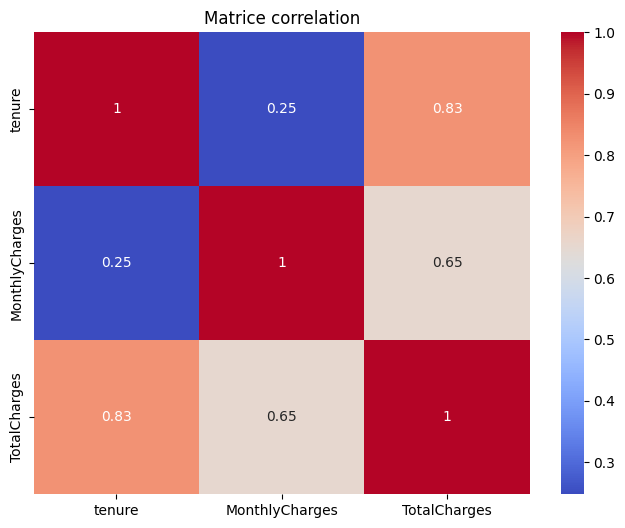

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm


corr_matrix = df[["tenure", "MonthlyCharges","TotalCharges"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Matrice correlation")
plt.show()

In [17]:
df.duplicated().sum()

np.int64(22)

In [18]:
df.dtypes # to check the data types of each column (to see if there are any columns that need to be converted to a different data type before building our model)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [19]:
df.isna().sum().sort_values(ascending=False) # to check the number of missing values in each column and sort them in descending order (to see which columns have the most missing values)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [20]:
df.dropna() # to drop rows with missing values (to handle missing values before building our model)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [21]:
df.isna().sum().sort_values(ascending=False) # to check the number of missing values in each column and sort them in descending order (to see if there are any remaining missing values after dropping rows with missing values)

TotalCharges        11
gender               0
Partner              0
SeniorCitizen        0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [22]:
df.select_dtypes(include=["int64", "float64"]).columns # to select only the numerical columns in the dataset (to perform numerical operations on these columns)
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe() # to get a statistical summary of the tenure, MonthlyCharges and TotalCharges columns (to see if there are any outliers in these columns that could affect our model)

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [23]:
df["expected_total"] = df["tenure"] * df["MonthlyCharges"] # to calculate the expected total charges for each customer based on their tenure and monthly charges (to see if there are any discrepancies between the expected total charges and the actual total charges that could indicate data quality issues or outliers)
(df["TotalCharges"] < df["expected_total"]).sum() #to check how many rows have a TotalCharges value that is less than the expected total charges (to see if there are any significant discrepancies between the actual total charges and the expected total charges that could indicate data quality issues or outliers)

np.int64(3214)

In [24]:
df["expected_total"] = df["tenure"] * df["MonthlyCharges"] # to calculate the expected total charges for each customer based on their tenure and monthly charges (to see if there are any discrepancies between the expected total charges and the actual total charges that could indicate data quality issues or outliers)
(df["TotalCharges"] < df["expected_total"] * 0.5).sum() # to check how many rows have a TotalCharges value that is less than 50% of the expected total charges (to see if there are any significant discrepancies between the actual total charges and the expected total charges that could indicate data quality issues or outliers)

np.int64(0)

In [25]:
import matplotlib.pyplot as plt

In [26]:
df["difference"] = df["TotalCharges"] - df["expected_total"]# to calculate the difference between the actual total charges and the expected total charges (to see if there are any significant discrepancies between these two values that could indicate data quality issues or outliers)
mean_difference = df["difference"].mean() # to calculate the mean of the difference between the actual total charges and the expected total charges (to see if there is a systematic bias in the data where the actual total charges are consistently higher or lower than the expected total charges)
std_difference = df["difference"].std() # to calculate the standard deviation of the difference between the actual total charges and the expected total charges (to see how much variability there is in the difference between these two values)

In [27]:
print("Moyenne :", mean_difference)
print("Écart-type :", std_difference)

Moyenne : 0.15319254835039567
Écart-type : 67.25532626764843


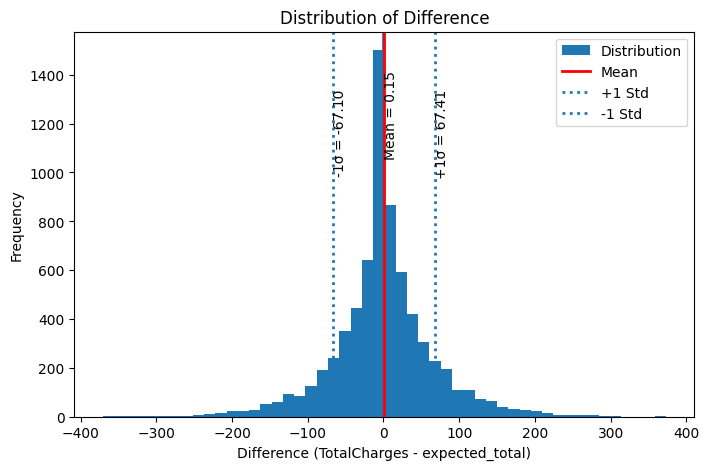

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["difference"].dropna(), bins=50, label="Distribution")
plt.axvline(0, linewidth=2)

#Ajouter des lignes verticales pour la moyenne et les écarts-types
plt.axvline(mean_difference, color="red", linewidth=2, label="Mean")
plt.axvline(mean_difference + std_difference, linestyle=":", linewidth=2, label="+1 Std")
plt.axvline(mean_difference - std_difference, linestyle=":", linewidth=2, label="-1 Std")

#Annoter les lignes verticales avec les valeurs correspondantes
ymax = plt.ylim()[1]
plt.text(mean_difference, ymax * 0.90, f"Mean = {mean_difference:.2f}", rotation=90, va="top")
plt.text(mean_difference + std_difference, ymax * 0.85, f"+1σ = {(mean_difference + std_difference):.2f}", rotation=90, va="top")
plt.text(mean_difference - std_difference, ymax * 0.85, f"-1σ = {(mean_difference - std_difference):.2f}", rotation=90, va="top")

plt.xlabel("Difference (TotalCharges - expected_total)")
plt.ylabel("Frequency")
plt.title("Distribution of Difference")
plt.legend()  # Affiche la légende
plt.show()


In [29]:
df = df.drop(columns=["expected_total"])
df = df.drop(columns=["difference"])

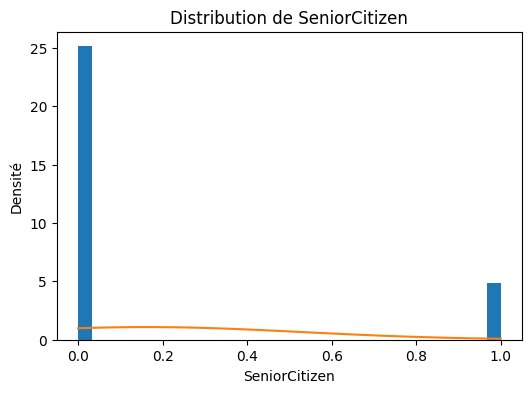

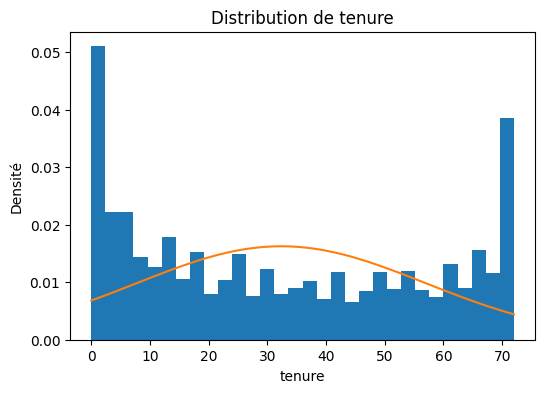

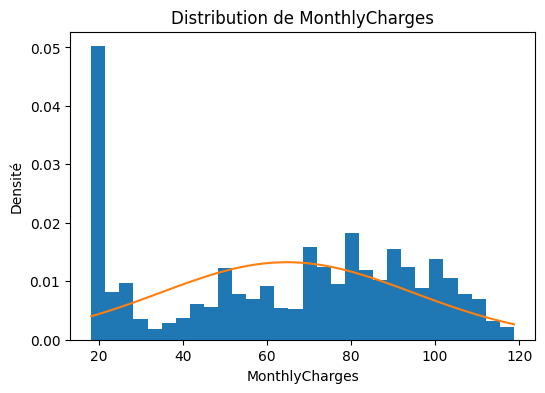

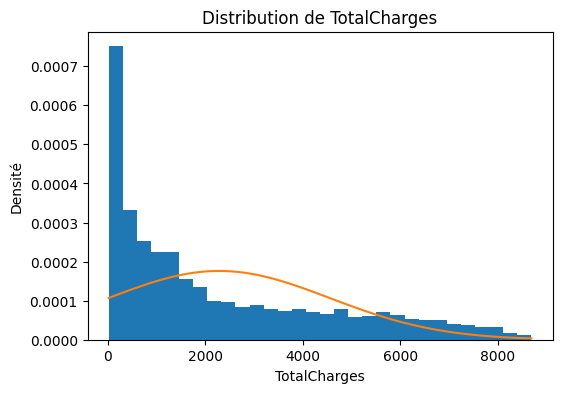

In [30]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    values = df[col].dropna()
    
    plt.hist(values, bins=30, density=True)
    
    mean = np.mean(values)
    std = np.std(values)
    
    x = np.linspace(values.min(), values.max(), 100)
    plt.plot(x, norm.pdf(x, mean, std))
    
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Densité")
    
    plt.show()

# 3- Créer y (cible) et X (variables explicatives) 

In [31]:
print(df["Churn"].unique())
print(df["Churn"].value_counts())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [32]:
y = (df["Churn"] == "Yes").astype(int) # to convert the target variable into a binary variable (1 for Yes and 0 for No)
print(y.value_counts())
print(y.value_counts(normalize=True) * 100) 

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [33]:
X = df.drop(columns=["Churn"]) #to create the feature matrix by dropping the target variable (to prepare the data for building our model)
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


# Train/Test split (séparer apprentissage et évaluation)

In [34]:
from sklearn.model_selection import train_test_split # for splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler # for feature scaling

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # to split the dataset into training and testing sets (to evaluate the performance of our model on unseen data)

In [36]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(5634, 19) (1409, 19)
(5634,) (1409,)


In [37]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


# Prétraitement des données

In [38]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns


C:\Users\DIATECH\AppData\Local\Temp\ipykernel_41884\2515403618.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns


In [39]:
print("Numériques :", list(num_cols))
print("Catégorielles :", list(cat_cols))


Numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [40]:
from sklearn.pipeline import Pipeline # for creating a pipeline that combines multiple steps (such as imputation, scaling and encoding) into a single object that can be used to fit and transform the data in one step
from sklearn.impute import SimpleImputer # for handling missing values by replacing them with a specified strategy (such as mean, median or most frequent value)
from sklearn.preprocessing import StandardScaler # for feature scaling 
from sklearn.preprocessing import OneHotEncoder # for encoding categorical variables using one-hot encoding (to convert categorical variables into a format that can be used by machine learning algorithms)
from sklearn.compose import ColumnTransformer # for applying different transformations to different columns (to apply imputation and scaling to numerical columns and one-hot encoding to categorical columns)
from sklearn.ensemble import RandomForestRegressor #

In [41]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
], verbose=True) # to create a pipeline for the numerical columns that first imputes missing values using the median strategy and then scales the features using standard scaling (to handle missing values and to ensure that the numerical features are on the same scale)

In [42]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
], verbose=True) # to create a pipeline for the categorical columns that first imputes missing values using the most frequent value strategy and then applies one-hot encoding (to handle missing values and to convert categorical variables into a format that can be used by machine learning algorithms)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ],
    remainder="drop"
)


In [44]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
print(X_train_prepared.shape)
print(X_test_prepared.shape)

[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.0s
[Pipeline] ............ (step 2 of 2) Processing scaler, total=   0.0s
[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.1s
[Pipeline] ............ (step 2 of 2) Processing onehot, total=   0.0s
(5634, 45)
(1409, 45)


In [45]:
X_train_prepared.shape, X_test_prepared.shape

((5634, 45), (1409, 45))

In [46]:
preprocessor.get_feature_names_out()# to get the names of the features after preprocessing (to see how the original features have been transformed and to be able to interpret the results of our model)

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__

# Entraîner un premier modèle (Régression Logistique)

In [47]:
from sklearn.linear_model import LogisticRegression # for building a logistic regression model (to predict the probability of a customer churning based on the features in the dataset)
from sklearn.ensemble import RandomForestClassifier

In [48]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
) # to create a logistic regression model with a maximum of 1000 iterations, balanced class weights and a random state of 42 (to ensure that the model converges and to handle class imbalance in the target variable)

In [49]:
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", log_reg)
], verbose=True) # to create a pipeline that combines the preprocessing steps and the logistic regression model into a single object that can be used to fit and predict the data in one step

In [50]:
print(model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())],
                                                           verbose=True),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                    

In [51]:
model.fit(X_train, y_train) # to fit the model on the training data (to train the model to learn the relationship between the features and the target variable)

[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.0s
[Pipeline] ............ (step 2 of 2) Processing scaler, total=   0.0s
[Pipeline] ........... (step 1 of 2) Processing imputer, total=   0.0s
[Pipeline] ............ (step 2 of 2) Processing onehot, total=   0.1s
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.1s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   0.1s


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,True
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Évaluer le modèle

In [52]:
y_pred = model.predict(X_test) # to predict the target variable on the test set (to evaluate the performance of our model on unseen data)
print(y_pred[:5])

[0 1 0 1 0]


In [53]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R2 :", r2)

RMSE : 0.5117498057968797
R2 : -0.3431527551732154


In [54]:
y_proba = model.predict_proba(X_test)[:, 1] # to predict the probabilities of the positive class (churn) on the test set (to evaluate the performance of our model using metrics that require probabilities, such as ROC AUC)
print(y_proba[:5])

[0.11547188 0.85307859 0.14683068 0.66066311 0.06043571]


In [55]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score # for evaluating the performance of our model using various metrics (to see how well our model is performing in terms of precision, recall, F1-score and ROC AUC)

In [56]:
confusion_matrix(y_test, y_pred)


array([[747, 288],
       [ 81, 293]])

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [58]:
roc_auc_score(y_test, y_proba)


0.8412978893797307

In [59]:
accuracy_score(y_test, y_pred) 

0.7381121362668559

# Comprendre ce que le modèle a appris

In [60]:
feature_names = model.named_steps["preprocessing"].get_feature_names_out()
print(feature_names)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_Month-

In [64]:
import joblib
joblib.dump(model, "Logistic_Regression_churn.pkl") # to save the trained model to a file using joblib (to be able to load the model later and use it for making predictions on new data)

['Logistic_Regression_churn.pkl']

In [62]:
loaded_model = joblib.load("random_forest_churn.pkl")
y_pred_loaded = loaded_model.predict(X_test)

print("R2 (modèle chargé):", r2_score(y_test, y_pred_loaded))

R2 (modèle chargé): -0.3431527551732154


In [66]:
coefs = model.named_steps["classifier"].coef_[0]

fi = (pd.DataFrame({"feature": feature_names, "coefficient": coefs})
        .sort_values("coefficient", key=lambda s: s.abs(), ascending=False))

fi.head(15) 

,feature,coefficient
1,num__tenure,-1.123589
38,cat__Contract_Two year,-0.781257
16,cat__InternetService_Fiber optic,0.705336
2,num__MonthlyCharges,-0.663581
36,cat__Contract_Month-to-month,0.663399
15,cat__InternetService_DSL,-0.621009
3,num__TotalCharges,0.457211
35,cat__StreamingMovies_Yes,0.274978
25,cat__DeviceProtection_No internet service,-0.274568
17,cat__InternetService_No,-0.274568


In [ ]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(10))


                                feature  importance
3                     num__TotalCharges    0.159271
1                           num__tenure    0.139823
2                   num__MonthlyCharges    0.137574
36         cat__Contract_Month-to-month    0.051714
18               cat__OnlineSecurity_No    0.032086
43  cat__PaymentMethod_Electronic check    0.030798
16     cat__InternetService_Fiber optic    0.027810
27                  cat__TechSupport_No    0.027064
0                    num__SeniorCitizen    0.019781
4                    cat__gender_Female    0.017738
